In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import preprocessing
import matplotlib.pyplot as plt
%matplotlib inline

import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_predict

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import cross_val_score


In [31]:
df= pd.read_csv('plants_enriched.csv')
df.head()

,LandCover,NDVI,Precipitation_mm_day,Temperature_C,gdd_cumulative_random,land_year_used,latitude,longitude,observation_window_end,observation_window_start,observed_on,original_index,phenophase,season_start,species,t_base
0,13,0.276763,1.806875,17.997247,304.144682,2023,41.549033,-73.035239,2023-07-01,2023-05-30,2023-10-25,527,fruiting,2023-09-22,Ailanthus_altissima,5
1,4,0.556369,2.424969,18.810632,537.146501,2023,38.842816,-78.393929,2023-07-01,2023-05-30,2023-12-29,585,fruiting,2023-09-22,Ailanthus_altissima,5
2,8,0.151666,7.270499,23.355127,799.928926,2023,29.795578,121.156275,2023-07-01,2023-05-30,2023-12-02,586,fruiting,2023-09-22,Ailanthus_altissima,5
3,13,NaN,2.297219,18.977899,507.415129,2023,40.770649,-73.951553,2023-07-01,2023-05-30,2023-12-17,587,fruiting,2023-09-22,Ailanthus_altissima,5
4,13,NaN,2.297219,18.977899,503.680560,2023,40.772956,-73.955893,2023-07-01,2023-05-30,2023-12-15,588,fruiting,2023-09-22,Ailanthus_altissima,5


In [32]:
df.isnull().sum()

LandCover                     0
NDVI                        348
Precipitation_mm_day          0
Temperature_C                 0
gdd_cumulative_random         0
land_year_used                0
latitude                      0
longitude                     0
observation_window_end        0
observation_window_start      0
observed_on                   0
original_index                0
phenophase                    0
season_start                  0
species                       0
t_base                        0
dtype: int64

In [33]:
df.shape

(13185, 16)

In [34]:
df['NDVI'].fillna(df['NDVI'].median())

0        0.276763
1        0.556369
2        0.151666
3        0.392768
4        0.392768
           ...   
13180    0.338013
13181    0.392768
13182    0.524494
13183    0.433110
13184    0.392768
Name: NDVI, Length: 13185, dtype: float64

In [35]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df[['NDVI']] = imputer.fit_transform(df[['NDVI','Precipitation_mm_day','Temperature_C']])[:,0:1]


In [64]:
df.head(100)

,LandCover,NDVI,Precipitation_mm_day,Temperature_C,gdd_cumulative_random,land_year_used,latitude,longitude,observation_window_end,observation_window_start,observed_on,original_index,phenophase,season_start,species,t_base,gdd_log,gdd_sqrt,gdd_cbrt,gdd_cbrt_capped
0,13,0.276763,1.806875,17.997247,304.144682,2023,41.549033,-73.035239,2023-07-01,2023-05-30,2023-10-25,527,fruiting,2023-09-22,Ailanthus_altissima,5,5.720786,17.439744,6.725017,6.725017
1,4,0.556369,2.424969,18.810632,537.146501,2023,38.842816,-78.393929,2023-07-01,2023-05-30,2023-12-29,585,fruiting,2023-09-22,Ailanthus_altissima,5,6.288131,23.176421,8.128884,8.128884
2,8,0.151666,7.270499,23.355127,799.928926,2023,29.795578,121.156275,2023-07-01,2023-05-30,2023-12-02,586,fruiting,2023-09-22,Ailanthus_altissima,5,6.685772,28.283015,9.282903,9.282903
3,13,0.477634,2.297219,18.977899,507.415129,2023,40.770649,-73.951553,2023-07-01,2023-05-30,2023-12-17,587,fruiting,2023-09-22,Ailanthus_altissima,5,6.231298,22.525877,7.976049,7.976049
4,13,0.477634,2.297219,18.977899,503.680560,2023,40.772956,-73.955893,2023-07-01,2023-05-30,2023-12-15,588,fruiting,2023-09-22,Ailanthus_altissima,5,6.223926,22.442829,7.956433,7.956433
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,13,0.208878,1.097656,20.786584,2014.632526,2024,39.744146,-105.037477,2024-07-01,2024-05-30,2024-08-28,383,fruiting,2024-03-01,Ailanthus_altissima,5,7.608688,44.884658,12.629862,12.629862
96,13,0.509606,4.459531,20.522607,2066.410675,2024,42.552419,-71.197094,2024-07-01,2024-05-30,2024-08-28,384,fruiting,2024-03-01,Ailanthus_altissima,5,7.634052,45.457790,12.737149,12.737149
97,13,0.485872,3.925625,20.244897,2083.897072,2024,42.286715,-71.373239,2024-07-01,2024-05-30,2024-08-28,385,fruiting,2024-03-01,Ailanthus_altissima,5,7.642475,45.649721,12.772976,12.772976
98,13,0.384494,2.379375,20.992242,2329.114262,2024,41.447825,-82.108701,2024-07-01,2024-05-30,2024-08-28,386,fruiting,2024-03-01,Ailanthus_altissima,5,7.753673,48.260898,13.255525,13.064876


In [37]:
df.isnull().sum()

LandCover                   0
NDVI                        0
Precipitation_mm_day        0
Temperature_C               0
gdd_cumulative_random       0
land_year_used              0
latitude                    0
longitude                   0
observation_window_end      0
observation_window_start    0
observed_on                 0
original_index              0
phenophase                  0
season_start                0
species                     0
t_base                      0
dtype: int64

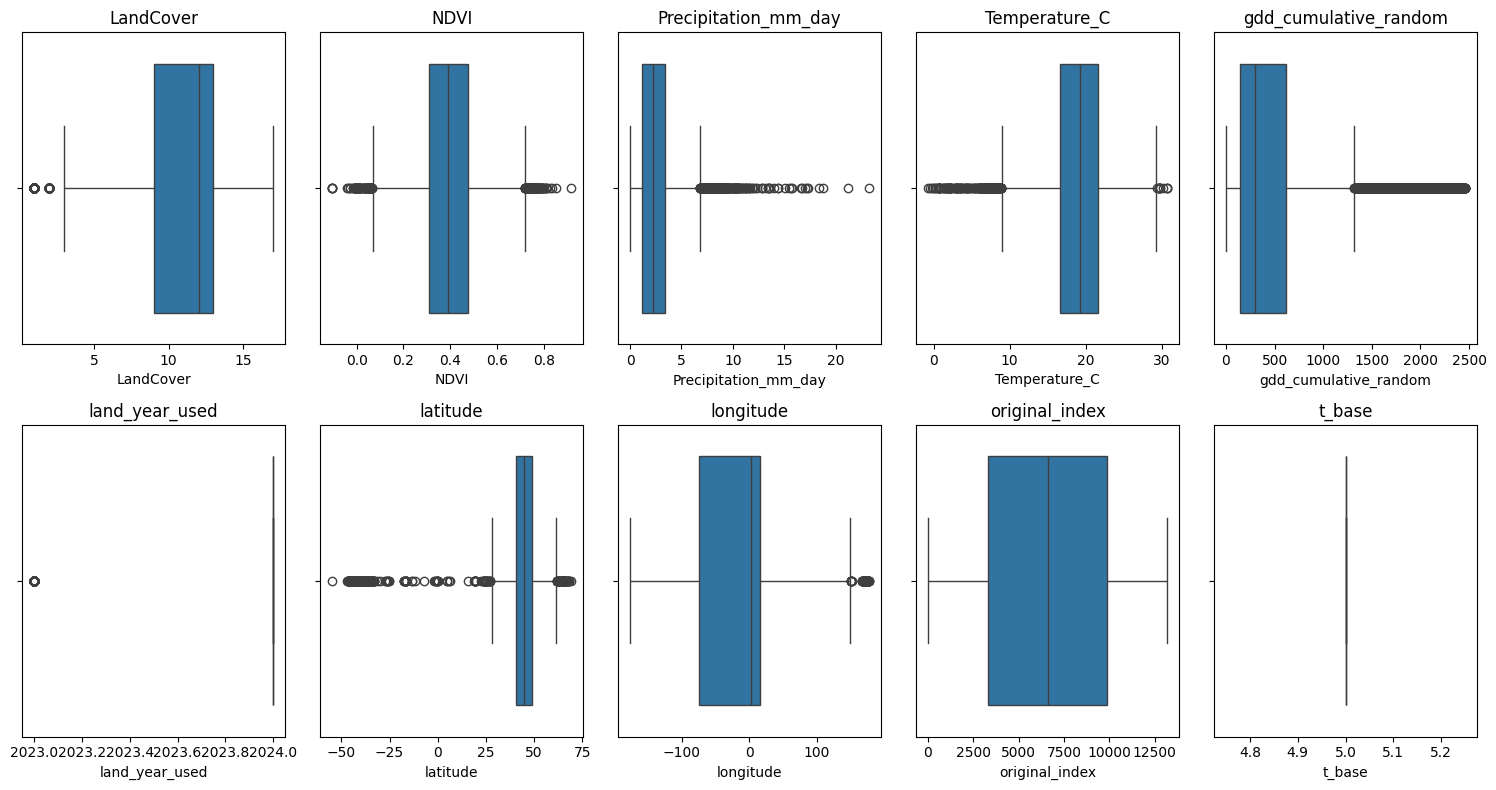

In [38]:
# Select only numeric columns
num_cols = df.select_dtypes(include=['float64','int64']).columns

plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, (len(num_cols)+1)//2, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [39]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

outlier_summary


{'LandCover': 378,
 'NDVI': 189,
 'Precipitation_mm_day': 420,
 'Temperature_C': 392,
 'gdd_cumulative_random': 1348,
 'land_year_used': 365,
 'latitude': 572,
 'longitude': 365,
 'original_index': 0,
 't_base': 0}

In [40]:
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]


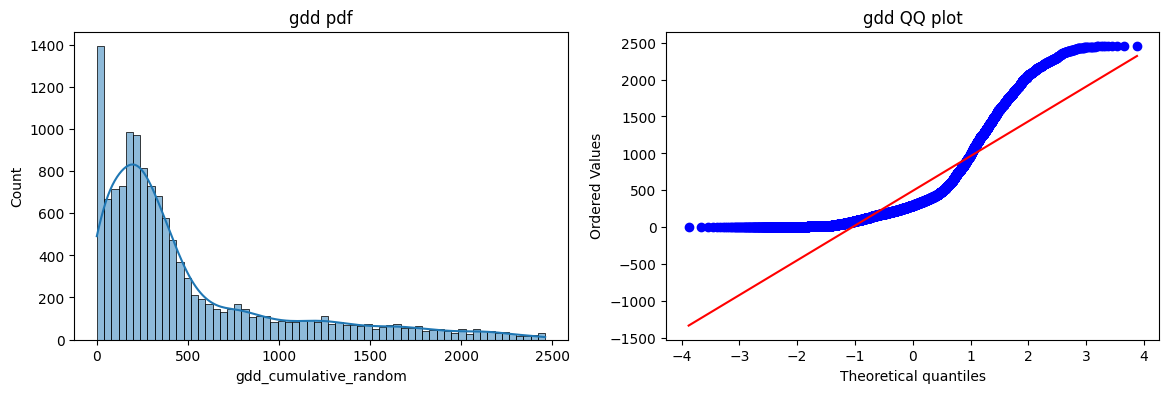

In [41]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(df['gdd_cumulative_random'],kde=True)
plt.title('gdd pdf')

plt.subplot(1,2,2)
stats.probplot(df['gdd_cumulative_random'], dist="norm",plot=plt)
plt.title('gdd QQ plot')

plt.show()

In [42]:
df['gdd_log'] = np.log1p(df['gdd_cumulative_random']) 

In [43]:
df.head()

,LandCover,NDVI,Precipitation_mm_day,Temperature_C,gdd_cumulative_random,land_year_used,latitude,longitude,observation_window_end,observation_window_start,observed_on,original_index,phenophase,season_start,species,t_base,gdd_log
0,13,0.276763,1.806875,17.997247,304.144682,2023,41.549033,-73.035239,2023-07-01,2023-05-30,2023-10-25,527,fruiting,2023-09-22,Ailanthus_altissima,5,5.720786
1,4,0.556369,2.424969,18.810632,537.146501,2023,38.842816,-78.393929,2023-07-01,2023-05-30,2023-12-29,585,fruiting,2023-09-22,Ailanthus_altissima,5,6.288131
2,8,0.151666,7.270499,23.355127,799.928926,2023,29.795578,121.156275,2023-07-01,2023-05-30,2023-12-02,586,fruiting,2023-09-22,Ailanthus_altissima,5,6.685772
3,13,0.477634,2.297219,18.977899,507.415129,2023,40.770649,-73.951553,2023-07-01,2023-05-30,2023-12-17,587,fruiting,2023-09-22,Ailanthus_altissima,5,6.231298
4,13,0.477634,2.297219,18.977899,503.680560,2023,40.772956,-73.955893,2023-07-01,2023-05-30,2023-12-15,588,fruiting,2023-09-22,Ailanthus_altissima,5,6.223926


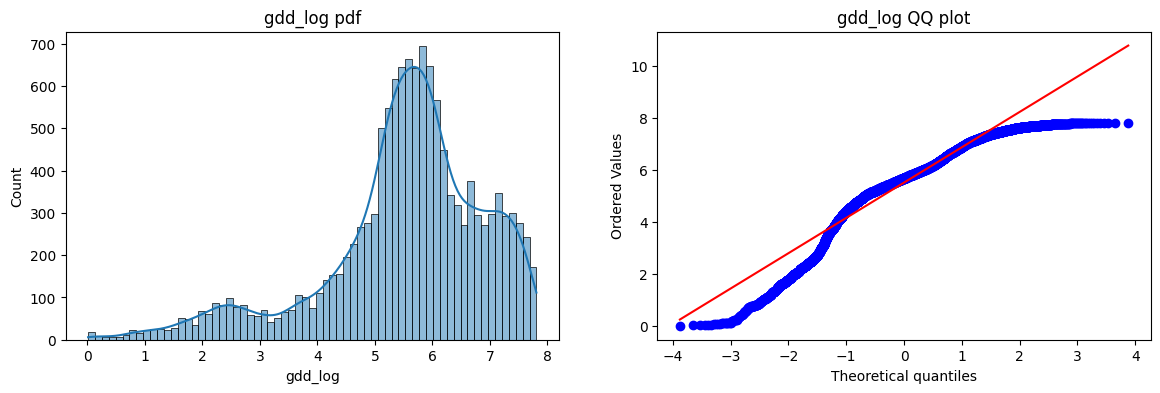

In [44]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(df['gdd_log'],kde=True)
plt.title('gdd_log pdf')

plt.subplot(1,2,2)
stats.probplot(df['gdd_log'], dist="norm",plot=plt)
plt.title('gdd_log QQ plot')

plt.show()

In [45]:
from scipy.stats import skew

skew(df['gdd_cumulative_random'])
skew(df['gdd_log'])


np.float64(-1.0530444528497906)

In [46]:
df['gdd_sqrt'] = np.sqrt(df['gdd_cumulative_random'])
df['gdd_cbrt'] = np.cbrt(df['gdd_cumulative_random'])


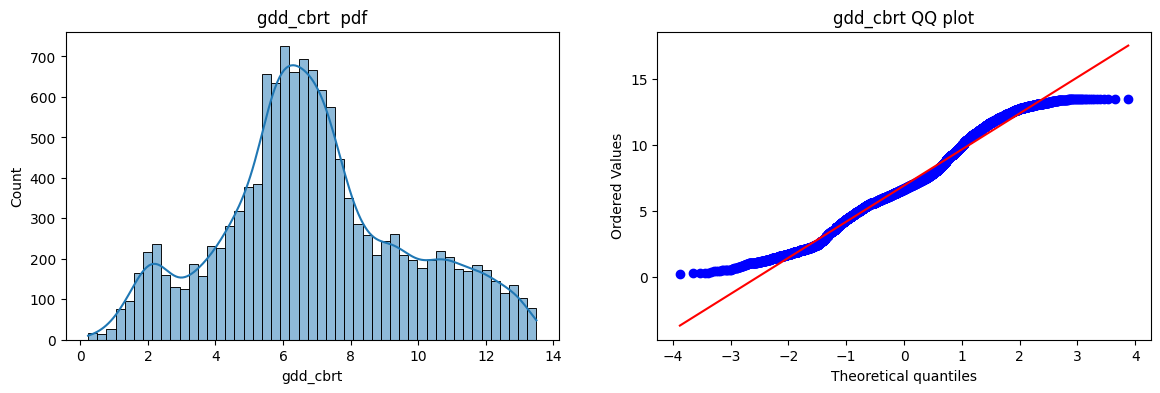

In [47]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.histplot(df['gdd_cbrt' ],kde=True)
plt.title('gdd_cbrt  pdf')

plt.subplot(1,2,2)
stats.probplot(df['gdd_cbrt' ], dist="norm",plot=plt)
plt.title('gdd_cbrt QQ plot')

plt.show()

In [48]:
skew(df['gdd_cumulative_random'])
skew(df['gdd_cbrt'])

np.float64(0.2264382693191745)

<Axes: xlabel='gdd_cbrt'>

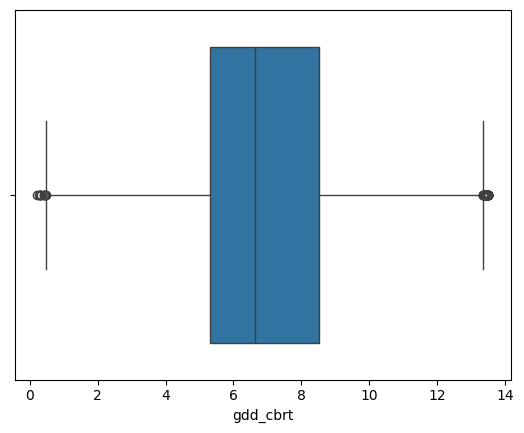

In [55]:
sns.boxplot(x='gdd_cbrt',data= df)

In [51]:
import numpy as np

Q1 = df['gdd_cbrt'].quantile(0.01)
Q3 = df['gdd_cbrt'].quantile(0.99)

df['gdd_cbrt_capped'] = np.where(df['gdd_cbrt'] < Q1, Q1,
                          np.where(df['gdd_cbrt'] > Q3, Q3, df['gdd_cbrt']))


In [57]:
df.head()

,LandCover,NDVI,Precipitation_mm_day,Temperature_C,gdd_cumulative_random,land_year_used,latitude,longitude,observation_window_end,observation_window_start,observed_on,original_index,phenophase,season_start,species,t_base,gdd_log,gdd_sqrt,gdd_cbrt,gdd_cbrt_capped
0,13,0.276763,1.806875,17.997247,304.144682,2023,41.549033,-73.035239,2023-07-01,2023-05-30,2023-10-25,527,fruiting,2023-09-22,Ailanthus_altissima,5,5.720786,17.439744,6.725017,6.725017
1,4,0.556369,2.424969,18.810632,537.146501,2023,38.842816,-78.393929,2023-07-01,2023-05-30,2023-12-29,585,fruiting,2023-09-22,Ailanthus_altissima,5,6.288131,23.176421,8.128884,8.128884
2,8,0.151666,7.270499,23.355127,799.928926,2023,29.795578,121.156275,2023-07-01,2023-05-30,2023-12-02,586,fruiting,2023-09-22,Ailanthus_altissima,5,6.685772,28.283015,9.282903,9.282903
3,13,0.477634,2.297219,18.977899,507.415129,2023,40.770649,-73.951553,2023-07-01,2023-05-30,2023-12-17,587,fruiting,2023-09-22,Ailanthus_altissima,5,6.231298,22.525877,7.976049,7.976049
4,13,0.477634,2.297219,18.977899,503.680560,2023,40.772956,-73.955893,2023-07-01,2023-05-30,2023-12-15,588,fruiting,2023-09-22,Ailanthus_altissima,5,6.223926,22.442829,7.956433,7.956433


In [53]:
def remove_outliers_percentile(df, column, percent=0.01):
    lower = df[column].quantile(percent)
    upper = df[column].quantile(1 - percent)
    
    df_clean = df[(df[column] >= lower) & (df[column] <= upper)]
    return df_clean

# Example for gdd_cbrt
df_clean = remove_outliers_percentile(df, "gdd_cbrt", percent=0.01)

print("Before:", df.shape)
print("After:", df_clean.shape)


Before: (13185, 20)
After: (12921, 20)


<Axes: xlabel='gdd_cbrt_capped'>

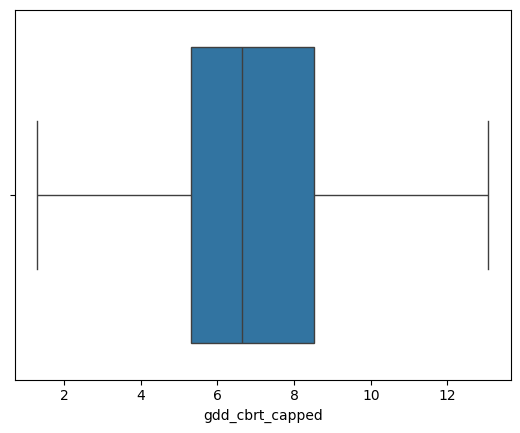

In [60]:
sns.boxplot(x='gdd_cbrt_capped',data=df)